In [2]:
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import Perceptron # used for simpele linear classificaction task
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential # Sequential lest you build a neural network layer by layer in keras
from tensorflow.keras.layers import Dense # dense makes the fianl predictions
from tensorflow.keras.layers import Dropout # Dropout prevents
from tensorflow.keras.utils import to_categorical # convert numeric class label into one hot encode fromate for training classification models
from tensorflow.keras.layers import Conv2D # conv2D extracts feature
from tensorflow.keras.layers import Flatten # Flatten reshapes them
from tensorflow.keras.layers import MaxPooling2D # maxpooling reduce the size 



In [4]:
df=pd.read_csv("fashion-mnist_train.csv")
df_test=pd.read_csv("fashion-mnist_test.csv")

In [5]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.shape


(60000, 785)

In [7]:
df.isnull().sum()

label       0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel780    0
pixel781    0
pixel782    0
pixel783    0
pixel784    0
Length: 785, dtype: int64

In [8]:
X_train=df.drop("label",axis=1).values
y_train=df["label"].values
X_test=df_test.drop("label",axis=1).values
y_test=df_test["label"].values


In [9]:
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0

In [10]:
X_train_img=X_train.reshape(-1,28,28)
X_test_img=X_test.reshape(-1,28,28)

In [11]:
X_train_img

array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0. 

In [12]:
y_train_cat=to_categorical(y_train,10)
y_test_cat=to_categorical(y_test,10)

In [13]:
perceptron=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation='softmax'),
])

In [14]:
perceptron.compile(optimizer='sgd',loss='categorical_crossentropy',metrics=['accuracy'])

In [15]:
history_percp=perceptron.fit(X_train_img,y_train_cat,validation_data=(X_test_img,y_test_cat),verbose=1,epochs=10,batch_size=32)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7354 - loss: 0.8326 - val_accuracy: 0.7947 - val_loss: 0.6416
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8048 - loss: 0.5971 - val_accuracy: 0.8157 - val_loss: 0.5709
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8185 - loss: 0.5478 - val_accuracy: 0.8230 - val_loss: 0.5370
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8255 - loss: 0.5211 - val_accuracy: 0.8301 - val_loss: 0.5163
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8312 - loss: 0.5036 - val_accuracy: 0.8359 - val_loss: 0.5006
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8348 - loss: 0.4908 - val_accuracy: 0.8353 - val_loss: 0.4946
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8374 - loss: 0.4811 - val_accuracy: 0.8419 - val_loss: 0.4812
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8390 - loss: 0.4733 - 

In [16]:
acc_percp=perceptron.evaluate(X_test_img,y_test_cat,verbose=0)[1]

In [17]:
acc_percp

0.8460000157356262

#ANN

In [18]:
ann=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax'),
])

In [19]:
ann.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [20]:
history_ann=ann.fit(X_train_img,y_train_cat,validation_data=(X_test_img,y_test_cat),verbose=1,epochs=10,batch_size=32)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8230 - loss: 0.5013 - val_accuracy: 0.8571 - val_loss: 0.3954
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8652 - loss: 0.3714 - val_accuracy: 0.8717 - val_loss: 0.3500
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8770 - loss: 0.3377 - val_accuracy: 0.8757 - val_loss: 0.3397
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8844 - loss: 0.3127 - val_accuracy: 0.8759 - val_loss: 0.3496
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8901 - loss: 0.2966 - val_accuracy: 0.8846 - val_loss: 0.3140
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8968 - loss: 0.2816 - val_accuracy: 0.8766 - val_loss: 0.3408
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8995 - loss: 0.2688 - val_accuracy: 0.8847 - val_loss: 0.3082
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9036 - loss: 0.2577 - 

In [21]:
acc_ann=ann.evaluate(X_test_img,y_test_cat,verbose=0)[1]

In [22]:
acc_ann

0.8898000121116638

In [23]:
X_train_cnn=X_train.reshape(-1,28,28,1)
X_test_cnn=X_test.reshape(-1,28,28,1)

In [24]:
cnn=Sequential([
    Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,3),activation='relu'),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])

In [25]:
cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [26]:
hisotry_cnn=cnn.fit(X_train_cnn,y_train_cat,validation_data=(X_test_cnn,y_test_cat),verbose=1,epochs=10,batch_size=32)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - accuracy: 0.8110 - loss: 0.5281 - val_accuracy: 0.8852 - val_loss: 0.3108
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8771 - loss: 0.3459 - val_accuracy: 0.9037 - val_loss: 0.2593
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8952 - loss: 0.2928 - val_accuracy: 0.9109 - val_loss: 0.2355
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9060 - loss: 0.2595 - val_accuracy: 0.9194 - val_loss: 0.2282
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9164 - loss: 0.2319 - val_accuracy: 0.9200 - val_loss: 0.2254
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9233 - loss: 0.2091 - val_accuracy: 0.9189 - val_loss: 0.2235
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.9289 - loss: 0.1914 - val_accuracy: 0.9256 - val_loss: 0.2140
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9346 - loss

In [27]:
acc_cnn=cnn.evaluate(X_test_cnn,y_test_cat,verbose=0)[1]

In [28]:
acc_cnn

0.9276999831199646

In [29]:
def plot_traning(history,title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'],label='train')
    plt.plot(history.history['val_accuracy'],label='val')
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'],label='train')
    plt.plot(history.history['val_loss'],label='val')
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

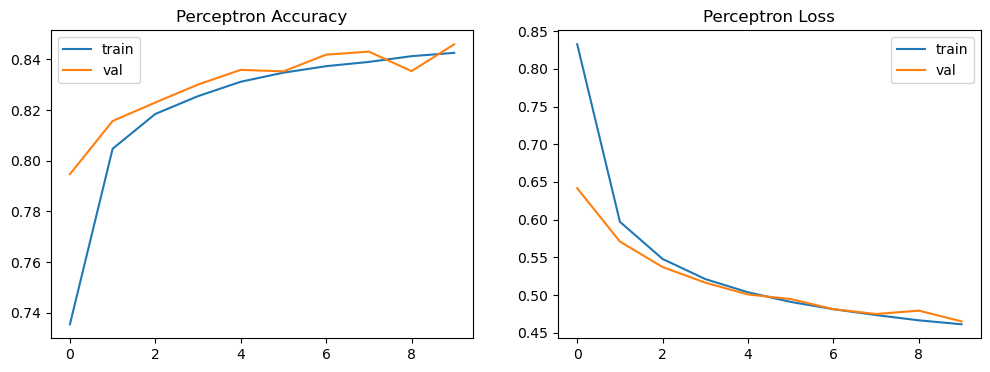

In [30]:
plot_traning(history_percp,"Perceptron")

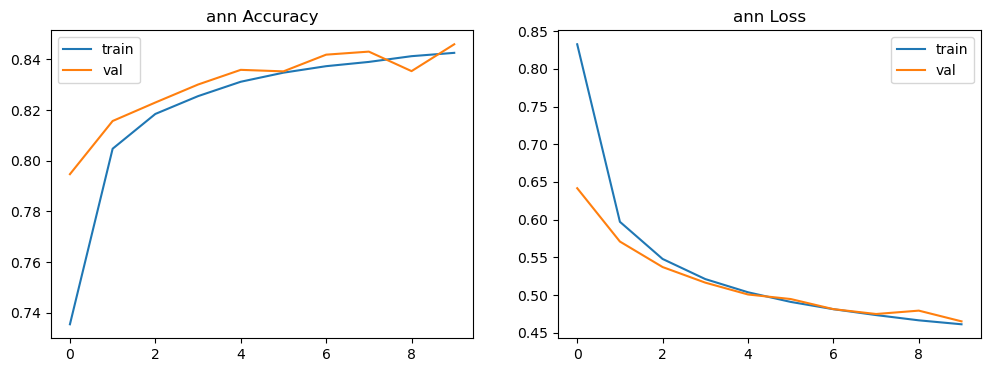

In [31]:
plot_traning(history_percp,"ann")

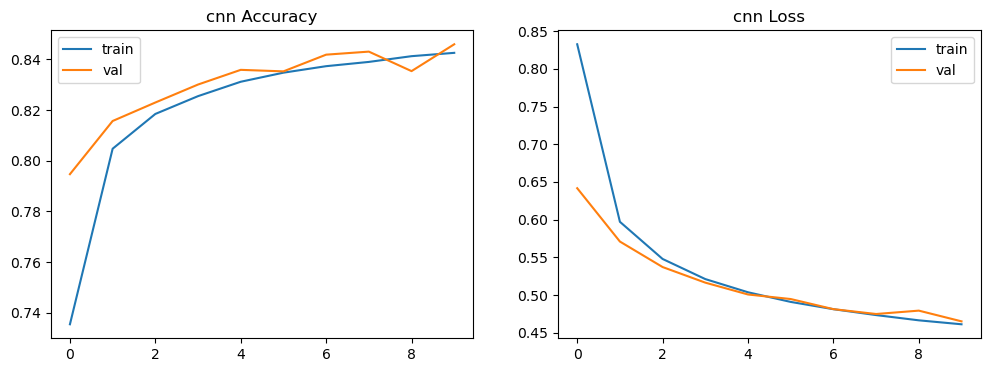

In [32]:
plot_traning(history_percp,"cnn")

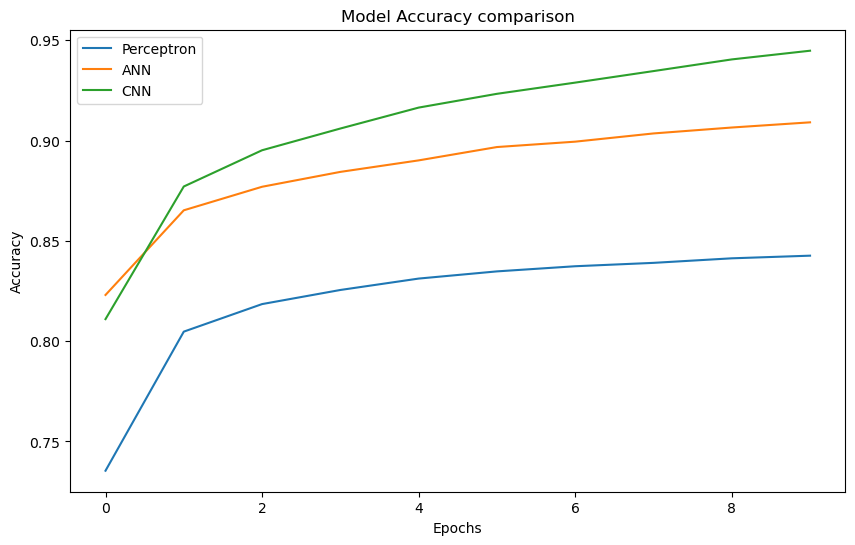

In [33]:
plt.figure(figsize=(10,6))
plt.plot(history_percp.history['accuracy'],label='Perceptron')
plt.plot(history_ann.history['accuracy'],label='ANN')
plt.plot(hisotry_cnn.history['accuracy'],label='CNN')
plt.title('Model Accuracy comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [34]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()
     

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


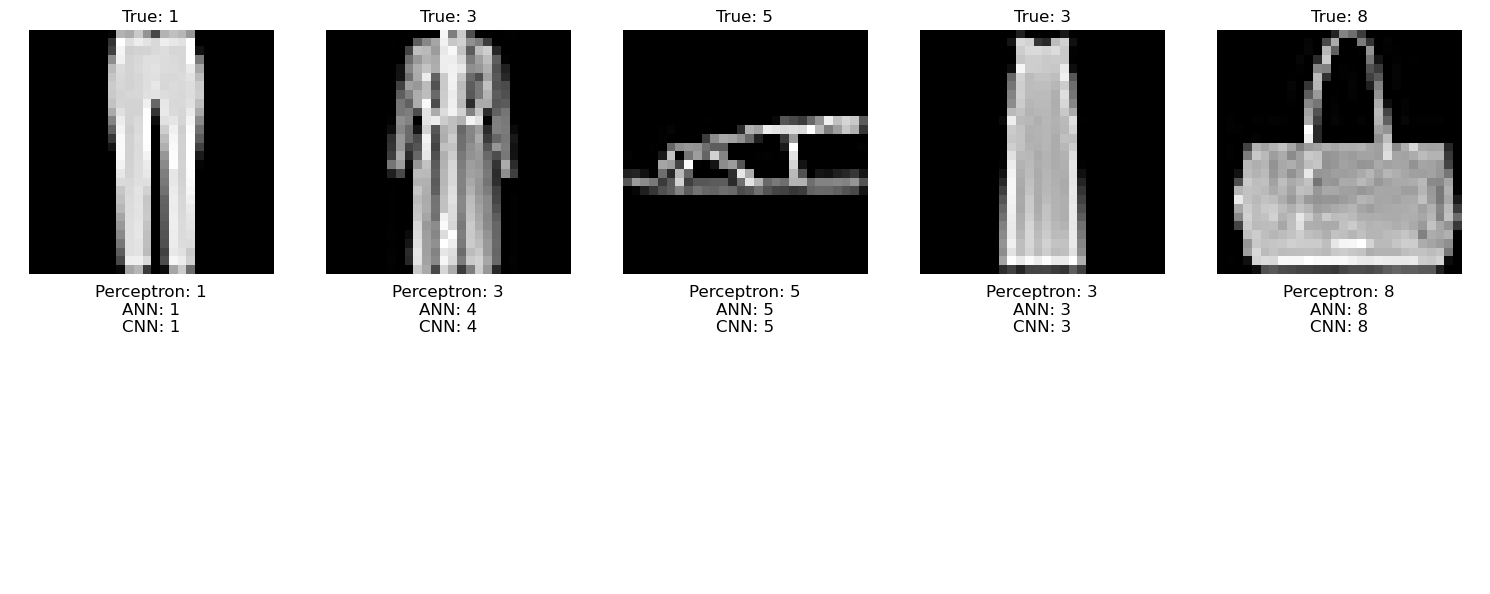

In [35]:

show_side_by_side([perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 5)
     

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


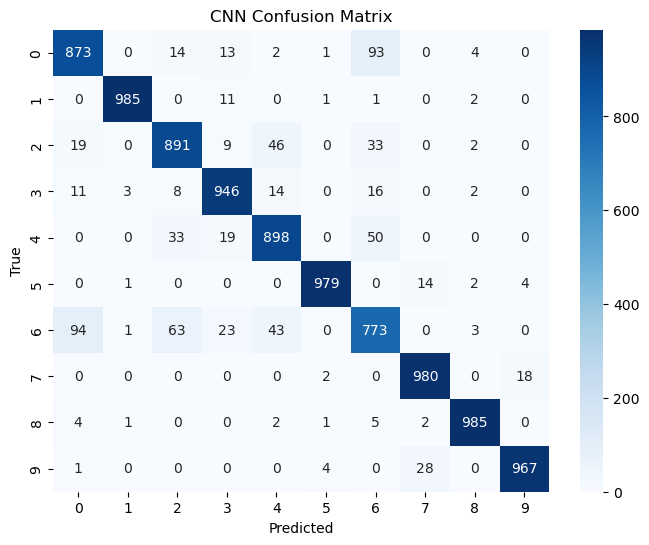

In [36]:
y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

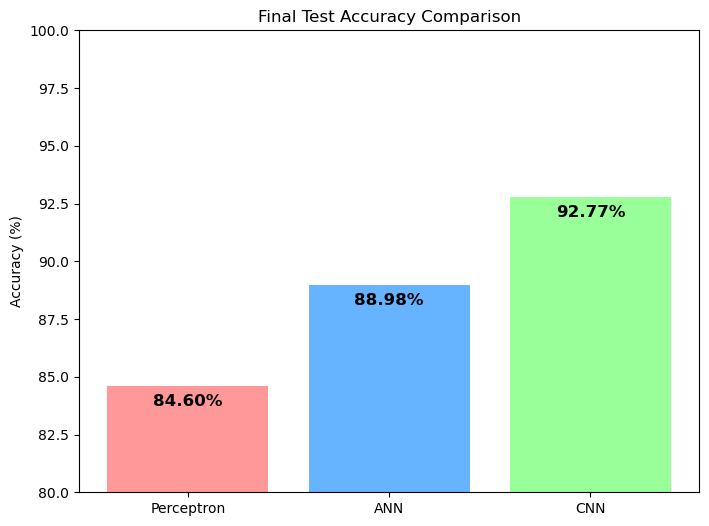

In [37]:
final_accs = [acc_percp*100, acc_ann*100, acc_cnn*100]
models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8,6))
bars = plt.bar(models, final_accs, color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(80, 100)
plt.show()

In [38]:
cnn.save("cnn_model.keras")

In [39]:
import pickle

In [ ]:
pickle.dump(cnn, open("cnn_model.keras", "wb"))